Data Analysis

In [17]:
!pip install -q seaborn matplotlib pandas numpy scipy scikit-learn biopython logomaker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 43.9 MB/s eta 0:00:00


In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from Bio import SeqIO

import logomaker

In [19]:
sns.set_theme(context='talk' ,style="whitegrid", palette="pastel")

In [20]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Load positive and negative datasets separately

In [24]:
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Bioinformatics_Project"
)

RAW_DIR = PROJECT_DIR / "data" / "raw"
PREP_DIR = PROJECT_DIR / "data" / "prepared"
CLUSTER_DIR = PREP_DIR / "clustered"
SPLIT_DIR = PREP_DIR / "splits"


positive = pd.read_csv(
    CLUSTER_DIR / "positive_nonredundant.tsv",
    sep="\t"
)

negative = pd.read_csv(
    CLUSTER_DIR / "negative_nonredundant.tsv",
    sep="\t"
)

print("Positive:", positive.shape)
print("Negative:", negative.shape)

display(positive.head())
display(negative.head())

Positive: (1104, 5)
Negative: (8622, 5)


,accession,organism,kingdom,protein_length,cleavage_position
0,O43155,Homo sapiens,Metazoa,660,35
1,O43866,Homo sapiens,Metazoa,347,19
2,O75629,Homo sapiens,Metazoa,220,31
3,O94985,Homo sapiens,Metazoa,981,28
4,P01579,Homo sapiens,Metazoa,166,23


,accession,organism,kingdom,protein_length,tm_helix_first_90
0,Q6YN16,Homo sapiens,Metazoa,418,False
1,Q9Y3I1,Homo sapiens,Metazoa,522,False
2,P30044,Homo sapiens,Metazoa,214,False
3,P07954,Homo sapiens,Metazoa,510,False
4,P21549,Homo sapiens,Metazoa,392,False


2. Load training and benchmark

In [25]:
training = pd.read_csv(
    SPLIT_DIR / "training_with_cv.tsv",
    sep="\t"
)

benchmark = pd.read_csv(
    SPLIT_DIR / "benchmark.tsv",
    sep="\t"
)

print("Training columns:")
print(training.columns.tolist())

print("\nBenchmark columns:")
print(benchmark.columns.tolist())

Training columns:
['accession', 'organism', 'kingdom', 'protein_length', 'cleavage_position', 'label', 'tm_helix_first_90', 'cv_fold']

Benchmark columns:
['accession', 'organism', 'kingdom', 'protein_length', 'cleavage_position', 'label', 'tm_helix_first_90']


3. If cleavage_position is missing, add it

In [26]:
positive_metadata = positive[
    [
        "accession",
        "cleavage_position"
    ]
]

In [27]:
if "cleavage_position" not in training.columns:

    training = training.merge(
        positive_metadata,
        on="accession",
        how="left"
    )

In [28]:
if "cleavage_position" not in benchmark.columns:

    benchmark = benchmark.merge(
        positive_metadata,
        on="accession",
        how="left"
    )

In [29]:
print(training.columns.tolist())
print(benchmark.columns.tolist())

['accession', 'organism', 'kingdom', 'protein_length', 'cleavage_position', 'label', 'tm_helix_first_90', 'cv_fold']
['accession', 'organism', 'kingdom', 'protein_length', 'cleavage_position', 'label', 'tm_helix_first_90']


In [30]:
training.to_csv(
    SPLIT_DIR / "training_with_cv.tsv",
    sep="\t",
    index=False
)

benchmark.to_csv(
    SPLIT_DIR / "benchmark.tsv",
    sep="\t",
    index=False
)

#Plots: composition plots

In [56]:
from Bio import SeqIO
from collections import Counter

def fasta_dict(path):
    return {
        (r.id.split("|")[1] if "|" in r.id else r.id): str(r.seq)
        for r in SeqIO.parse(path, "fasta")
    }

train_seq = fasta_dict(SPLIT_DIR / "training.fasta")
bench_seq = fasta_dict(SPLIT_DIR / "benchmark.fasta")

# Positive proteins only → extract their SP
train_sp = [
    train_seq[a][:int(c)]
    for a, c in training.loc[training.label == 1,
                             ["accession","cleavage_position"]].dropna().values
]

bench_sp = [
    bench_seq[a][:int(c)]
    for a, c in benchmark.loc[benchmark.label == 1,
                              ["accession","cleavage_position"]].dropna().values
]

In [57]:
AA = list("GAVLIMFWYSTCNQHDEKR")

def composition(seqs, name):
    c = Counter("".join(seqs))
    total = sum(c[a] for a in AA)

    return pd.DataFrame({
        "AA": AA,
        "Frequency": [100*c[a]/total for a in AA],
        "Dataset": name
    })

In [35]:
import requests

query = "(reviewed:true) AND (taxonomy_id:2759) AND (ft_signal:*)"

url = "https://rest.uniprot.org/uniprotkb/search"
params = {"query": query, "format": "json", "size": 500}

swissprot_sp = []

while True:
    r = requests.get(url, params=params)
    r.raise_for_status()

    for entry in r.json()["results"]:
        sequence = entry["sequence"]["value"]

        for feature in entry.get("features", []):
            if feature["type"] == "Signal":
                start = feature["location"]["start"].get("value")
                end = feature["location"]["end"].get("value")

                if start is not None and end is not None:
                    swissprot_sp.append(sequence[start-1:end])
                    break

    next_url = r.links.get("next", {}).get("url")

    if next_url is None:
        break

    url = next_url
    params = None

print("SwissProt SPs:", len(swissprot_sp))

SwissProt SPs: 33117


In [41]:
len(swissprot_sp)

33117

In [ ]:
swissprot_sp

In [ ]:
train_sp

In [60]:
composition_data = pd.concat([
    composition(train_sp, "Training SP"),
    composition(bench_sp, "Benchmark SP"),
    composition(swissprot_sp, "SwissProt SP")
])

In [61]:
plot_data

,protein_length,Dataset
0,660,Positive
1,347,Positive
2,220,Positive
3,981,Positive
4,166,Positive
...,...,...
8617,187,Negative
8618,151,Negative
8619,100,Negative
8620,113,Negative


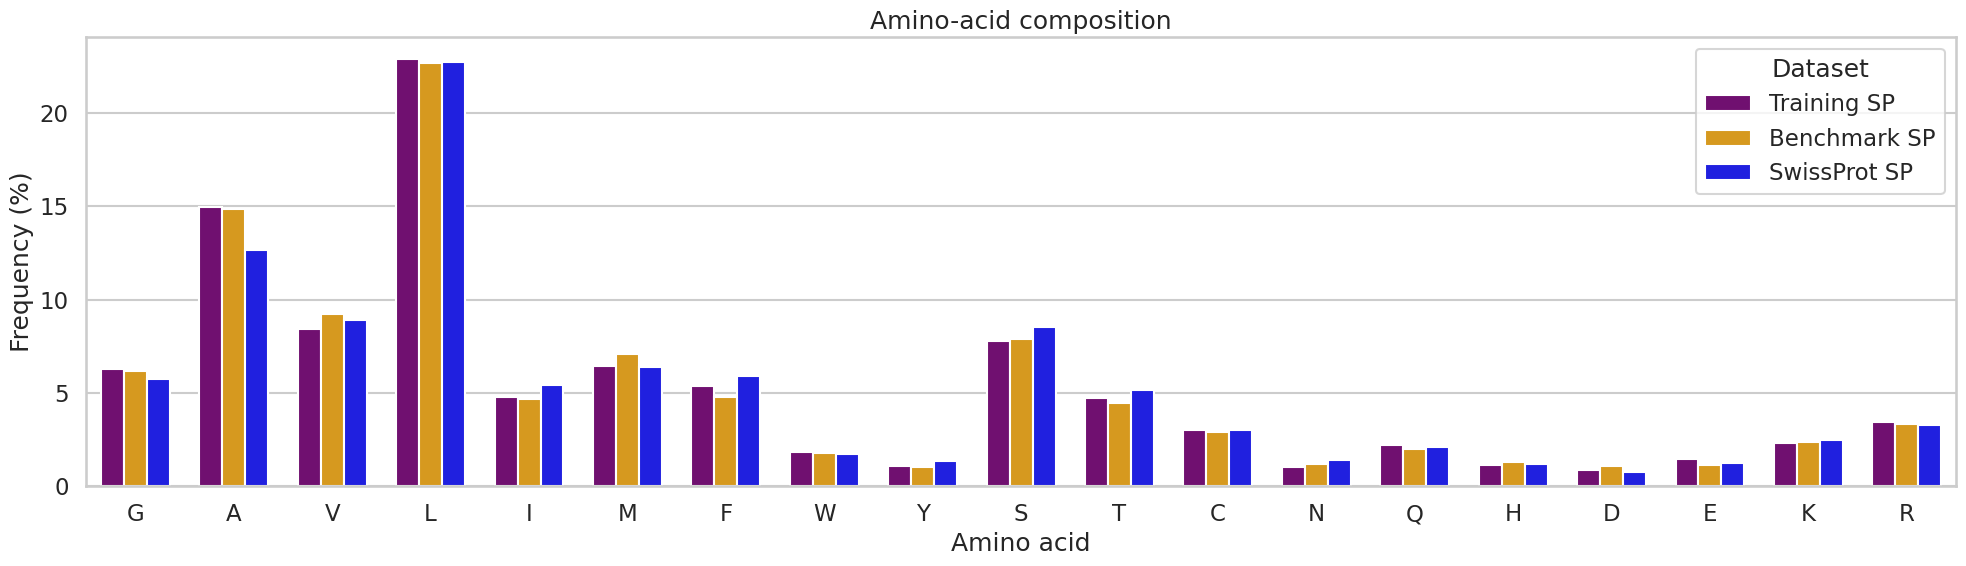

In [62]:
plt.figure(figsize=(20,6))

sns.barplot(
    data=composition_data,
    x="AA",
    y="Frequency",
    hue="Dataset",
    order=AA,
    width=0.7,
    palette={
        "Training SP": "purple",
        "Benchmark SP": "#F4A300",
        "SwissProt SP": "blue"
    }
)

plt.xlabel("Amino acid")
plt.ylabel("Frequency (%)")
plt.title("Amino-acid composition")
plt.tight_layout()
plt.show()

protein length

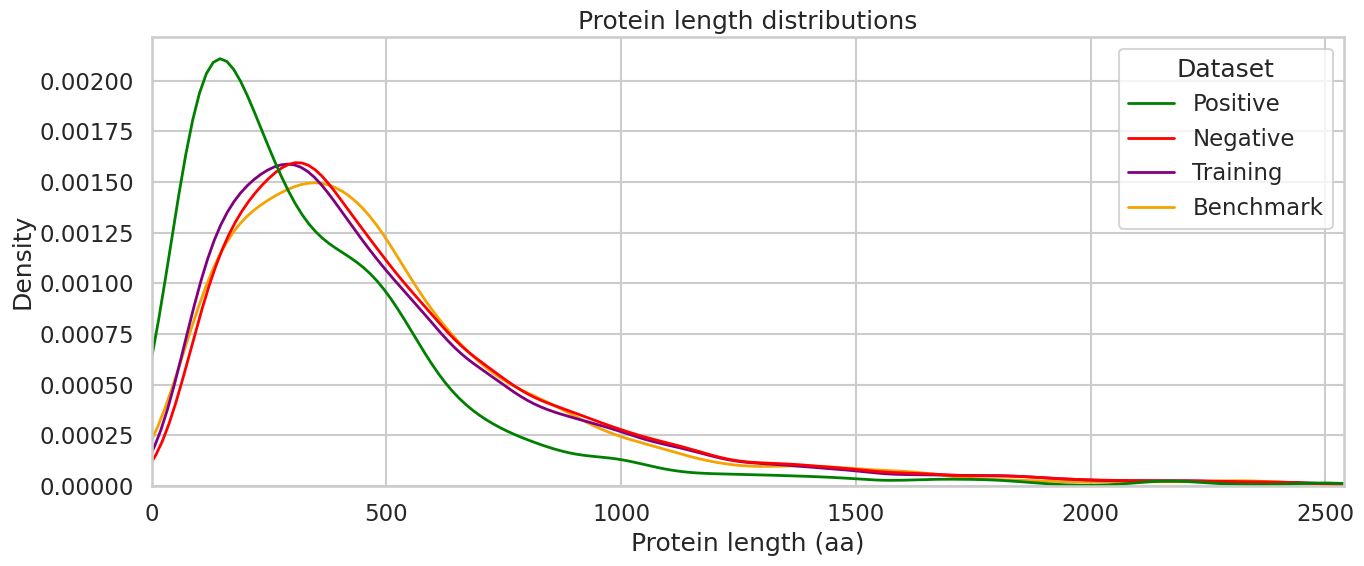

In [63]:
cutoff = length_data["protein_length"].quantile(0.99)

plot_lengths = length_data[
    length_data["protein_length"] <= cutoff
]

plt.figure(figsize=(14,6))

sns.kdeplot(
    data=plot_lengths,
    x="protein_length",
    hue="Dataset",
    common_norm=False,
    linewidth=2,
    bw_adjust=0.8,
    palette={
        "Positive": "green",
        "Negative": "red",
        "Training": "purple",
        "Benchmark": "#F4A300"
    }
)

plt.xlabel("Protein length (aa)")
plt.ylabel("Density")
plt.title("Protein length distributions")
plt.xlim(0, cutoff)
plt.tight_layout()
plt.show()

In [64]:
print("99th percentile:", cutoff)

99th percentile: 2540.0


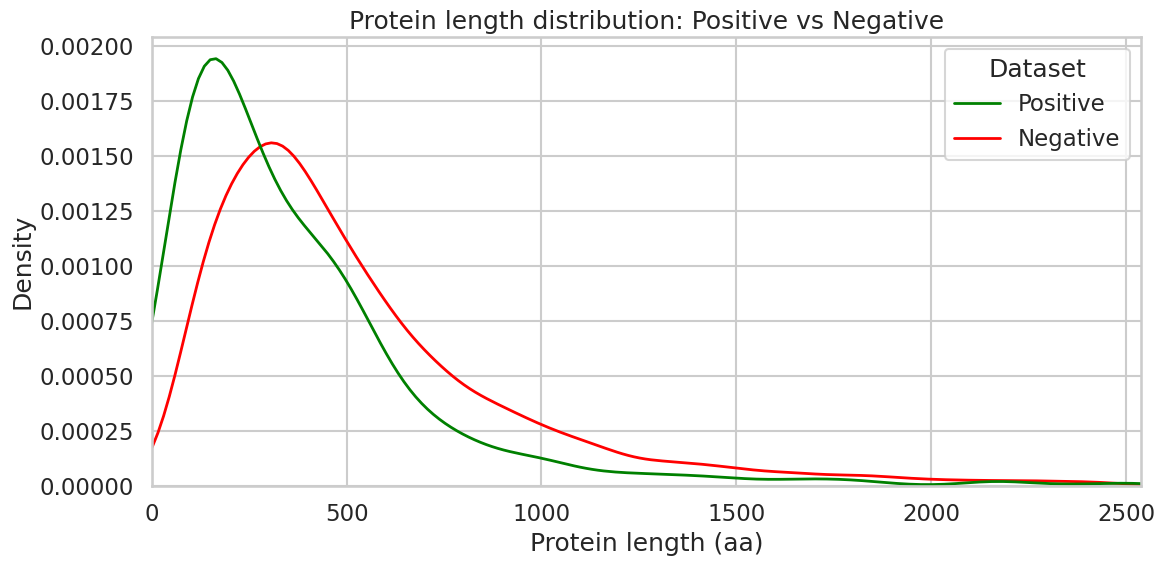

In [65]:
pos_neg_lengths = pd.concat([
    positive[["protein_length"]].assign(Dataset="Positive"),
    negative[["protein_length"]].assign(Dataset="Negative")
])

cutoff = pos_neg_lengths["protein_length"].quantile(0.99)

plot_data = pos_neg_lengths[
    pos_neg_lengths["protein_length"] <= cutoff
]

plt.figure(figsize=(12,6))

sns.kdeplot(
    data=plot_data,
    x="protein_length",
    hue="Dataset",
    common_norm=False,
    linewidth=2,
    palette={
        "Positive": "green",
        "Negative": "red"
    }
)

plt.xlabel("Protein length (aa)")
plt.ylabel("Density")
plt.title("Protein length distribution: Positive vs Negative")
plt.xlim(0, cutoff)
plt.tight_layout()
plt.show()

SP length

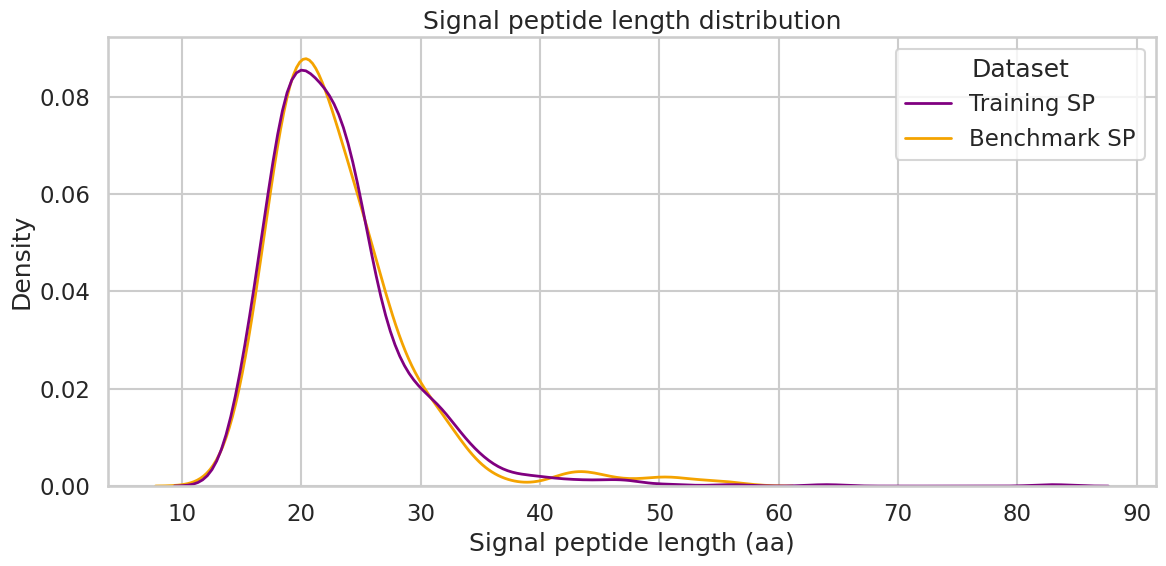

In [54]:
sp_lengths = pd.concat([
    training[training["label"] == 1][["cleavage_position"]]
        .rename(columns={"cleavage_position": "SP_length"})
        .assign(Dataset="Training SP"),

    benchmark[benchmark["label"] == 1][["cleavage_position"]]
        .rename(columns={"cleavage_position": "SP_length"})
        .assign(Dataset="Benchmark SP")
])

plt.figure(figsize=(12,6))

sns.kdeplot(
    data=sp_lengths,
    x="SP_length",
    hue="Dataset",
    common_norm=False,
    linewidth=2,
    palette={
        "Training SP": "purple",
        "Benchmark SP": "#F4A300"
    }
)

plt.xlabel("Signal peptide length (aa)")
plt.ylabel("Density")
plt.title("Signal peptide length distribution")
plt.tight_layout()
plt.show()

Taxonomic classification — 4 plots

In [76]:
pie_colors = sns.color_palette("pastel")

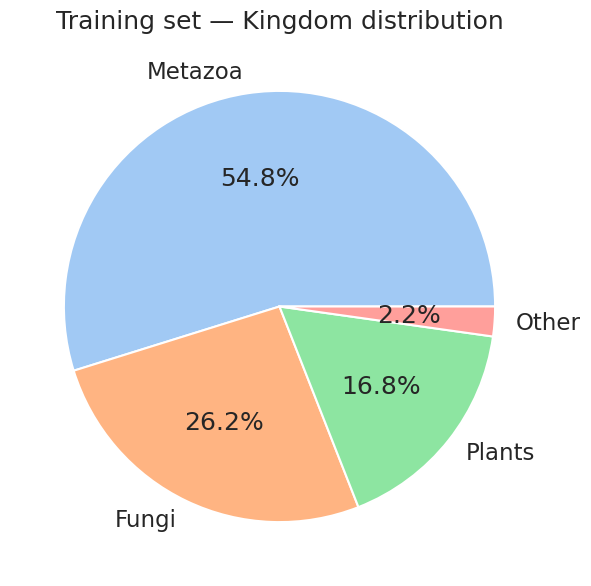

In [77]:
# 1. Training — Kingdom
counts = training["kingdom"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=pie_colors
)
plt.title("Training set — Kingdom distribution")
plt.show()

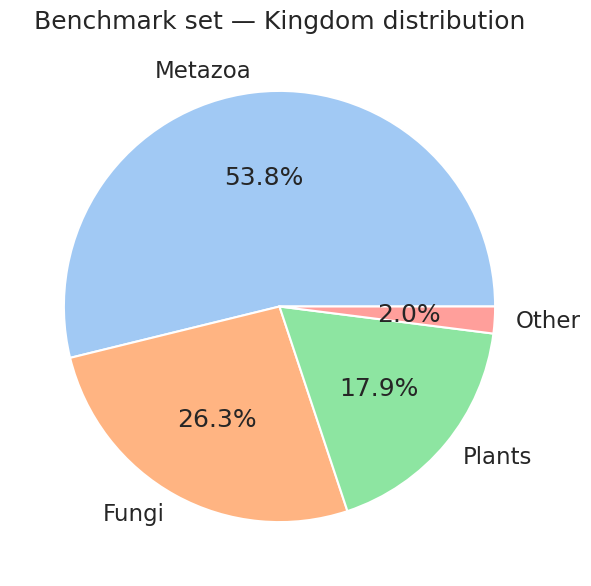

In [78]:
# 2. Benchmark — Kingdom
counts = benchmark["kingdom"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=pie_colors
)
plt.title("Benchmark set — Kingdom distribution")
plt.show()

In [91]:

# Short species names
train_species = training["organism"].str.split().str[:2].str.join(" ")
bench_species = benchmark["organism"].str.split().str[:2].str.join(" ")

train_top = train_species.value_counts().head(10)
bench_top = bench_species.value_counts().head(10)

# Same color mapping across both plots
all_species = list(dict.fromkeys(list(train_top.index) + list(bench_top.index)))
species_palette = sns.color_palette("pastel", len(all_species))

species_colors = dict(zip(all_species, species_palette))

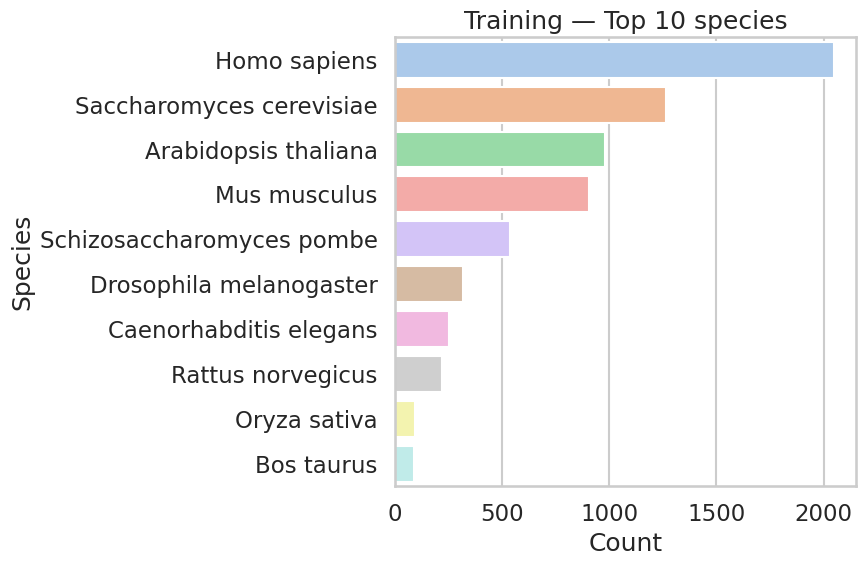

In [92]:
#3. training -- species
plt.figure(figsize=(9,6))

sns.barplot(
    x=train_top.values,
    y=train_top.index,
    palette=[species_colors[s] for s in train_top.index],
    hue=train_top.index,
    legend=False
)

plt.xlabel("Count")
plt.ylabel("Species")
plt.title("Training — Top 10 species")
plt.tight_layout()
plt.show()

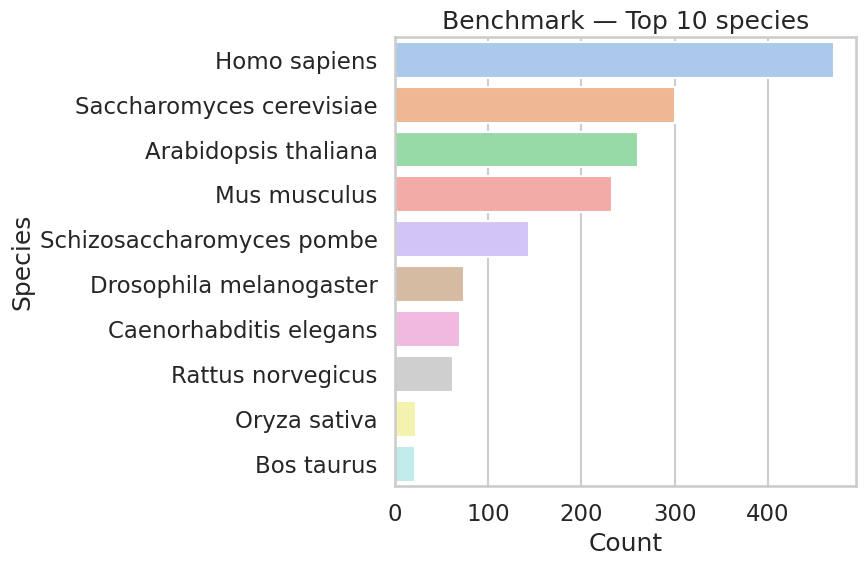

In [94]:
#4. benchmarking--species
plt.figure(figsize=(9,6))

sns.barplot(
    x=bench_top.values,
    y=bench_top.index,
    palette=[species_colors[s] for s in bench_top.index],
    hue=bench_top.index,
    legend=False
)

plt.xlabel("Count")
plt.ylabel("Species")
plt.title("Benchmark — Top 10 species")
plt.tight_layout()
plt.show()

sequence logos

In [86]:
def cleavage_windows(df, seq_dict):
    windows = []

    for _, row in df[
        (df["label"] == 1) &
        (df["cleavage_position"].notna())
    ].iterrows():

        acc = row["accession"]
        c = int(row["cleavage_position"])

        if acc in seq_dict:
            seq = seq_dict[acc]

            # -13 ... -1 | +1 +2
            if c >= 13 and len(seq) >= c + 2:
                windows.append(seq[c-13:c+2])

    return windows


train_windows = cleavage_windows(training, train_seq)
bench_windows = cleavage_windows(benchmark, bench_seq)

print("Training:", len(train_windows))
print("Benchmark:", len(bench_windows))
print("Window length:", len(train_windows[0]))
print(train_windows[:5])

Training: 883
Benchmark: 221
Window length: 15
['LLLFACCWAPGGANL', 'LALCLLLASPGLAWY', 'RVLVGAVLPAMLLAA', 'LLAALIATPAAFAIL', 'LFISAVLVSSVSAAT']


In [87]:
print("\n".join(train_windows))

LLLFACCWAPGGANL
LALCLLLASPGLAWY
RVLVGAVLPAMLLAA
LLAALIATPAAFAIL
LFISAVLVSSVSAAT
LAILTILMYSTAAKF
VVMAMLWVTPVRAGT
LLILTCLVAVALARP
AVSNLLVWEKVTSLP
VLLWLQLCALTQAVS
LLLSMLWMDMAMAGS
GIFLFLCSTPAWAKE
AFCVAMLVSDVSAKT
PGVGSALGRRTKRAQ
VLVAVATALVSSSSP
VVVVSLLVGASRAAN
LGLLLFLLPGSLGAE
FLVQGSLYLVICGQD
LSLALALALRPSDAG
DQPVPTPTPSVPTSS
LLVQIWALQEASSLS
LAVLLLKPSQLQSRE
LLVLCLQLGANKAQD
LWALAACFTPGESQR
LCVLSLAGVANAAEN
VAMSSGAPLLKIREE
LLSCLLLTGSSSGSK
LLLAALLAAGARASG
LLVLTLPGLPVWAQN
LAIVSLCLASIQASK
TILLFCLLGSTRSLP
VNILALTLPFLGAEV
LLLLLRATGFTCAQT
LVVGLAAVAGVDGAT
APGGLAPENASKRDQ
FLTLAVCSSLAYGKE
LLGLSWLCSPLGALV
SHMVDLQAAAQKLKR
ILIFLSFVALSSAGF
AVICFCLLGIASALP
TLLLWSQVSGAQGQE
TILCLTSTMGVSGDC
LLLALLHVYRALCEE
KSPGTEDYTRRSLLA
LCAAAALVACTRGDP
CVGVLGLSKLCGADS
FLMLLPWPLATLTST
LCGLALLCALSLGQR
VLVIFEVPEIKAQDS
LWMLPSLCKFSLAAL
FLLIASHWTLVQNIY
GIVLALLLALAGSER
AVSLCLLLFLTSALE
ALVVGAVLVSSAWGG
TLMIMIWMSLARASM
LLLLVSPAPVSAAGC
LLALALILPGTLCAE
FLLALTIIASTWALT
VVAFLAMVMGTHTYS
LSLLALGAAYVYAIP
FFLLLSLIGFCWAQY
LLALSLAQHGSLAAT
SAVLLVLV

In [88]:
print("\n".join(bench_windows))

GLLGATVVAAVSSMP
SIWVLFMAAQSLGKT
FFNLLLLLQAVISAD
LLLVLLRAGPVWPDS
MIIASLMIMGVEMDR
IYLFVTFFSTILAGS
LTALSILASLAVAKE
SLLSLALPGAALAAT
AVLLVAQPQLVHSHP
VATLVLLDHLSLARN
SLFLALLLATIVAAD
ISCLLLIGIVVECKE
LLLFLLQAVPGLGLP
LLLMVAAIGKTSAIY
GLLLALLLPVVGAST
LLVFFVNISFCFAAD
IFALLATICAAFAYV
VVTGLVVVVVATALS
RMAVAALAAGANAAS
VVFFAMVLASSQANE
ITLLLSVLQMSRGQR
SCIALSLALVTNSAP
AIFCISRLLCSHGAP
CSLVLCKVHLSQASP
VVLLLLSIVMAEPKR
LLLLLSLEAIVKAGI
SLVLCCFPDTAFGVE
LVSFLKDRHFCSADP
LMLLGFLCPRSSPCG
LIWLYMCVWMVHGKV
HAHHRLALRSVLATQ
LLASCSLSPTSLAET
VVLMLDRILFVPGTP
LAVSLGLIAALQAHH
VLGALALAGLGFPAP
AWLVALGAAQVAATA
SLLIATPGLLVSGAN
LLLPLLGTGPALGRG
LLPVFVAINLVHSSP
VLALLLCAGQVIALP
VVLALGCLRLGSGVN
IFLALLGAAVAFPVD
LLGLAALLGTSQSRT
LWLLLPLLGLVGASG
LLLLLLLPSPLHPHP
LLLLLLLPLPARAWY
LMVTPMTGARSDNSG
LFAAFEAPTMVEAQK
MVSLALCCYQAHALV
FSFFVLCVALATAGH
GALFLALLAGAHAEF
LLLVACFCSVAFGDC
WLLVLTPGRPAAGLS
AVLCLSLPTGCLSSQ
VLSLLVAAGISQASS
LVTLALLFTLSSAQY
VLSMLLTASDSWARR
VIIIFSTLTFSEAWV
LLLLLASSPLALGIP
VYRRDVTDEASAAAS
ALILACGVAGIQAEE
LVVLVALFALVTGSC
LAVLLAAH